In [1]:
import os
import numpy as np
import yaml
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.patches as mpatches
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, leaves_list

In [2]:
# =========================
# 1. Set paths
# =========================
save_dir = "/projects/b1042/GoyalLab/jaekj/KeepingScore/SCTAB_FINAL/Model_softmax/sample_mean_path_3000_true"   # <-- change if needed
ll_final_path = os.path.join(save_dir, "ll_final.npy")
ll_comp_path  = os.path.join(save_dir, "ll_comp.npy")
CELL_TYPE_PATH = "/projects/b1042/GoyalLab/jaekj/KeepingScore/merlin_cxg_2023_05_15_sf-log1p/categorical_lookup/cell_type.parquet"
BROAD_CELL_TYPE_MEMBERSHIP_PATH = "/projects/b1042/GoyalLab/jaekj/KeepingScore/SCTAB_FINAL/cell_type_clustering/kNN_mean_outputs/broad_cell_type_membership_k5.csv"
HIGH_LEVEL_CELLTYPE_PATH = "/projects/b1042/GoyalLab/jaekj/KeepingScore/SCTAB_FINAL/Model_softmax/high-level-celltype.yaml"
analysis_dir = os.path.join(save_dir, "path_3000_heatmap_analysis_k5")
permutation_dir = os.path.join(analysis_dir, "permutation_test_path3000")
# =========================

In [3]:
ref_class = globals().get("ref_class", 31)
top_k_dims = globals().get("top_k_dims", 200)
display_vmin = globals().get("display_vmin", -1.5)
display_vmax = globals().get("display_vmax", 1.5)
mean_path = globals().get("mean_path", None)

assignment_mode = "true"   # 'true' or 'pred'
n_perm = 100_000  # increase if needed
random_seed = 42
 
os.makedirs(analysis_dir, exist_ok=True)
os.makedirs(permutation_dir, exist_ok=True)
 
rng = np.random.default_rng(seed=random_seed)
sns.set_context("talk")
sns.set_style("white")

In [4]:
# ============================================================
# Cell-type hierarchy informed clustering for the relative lci heatmap
# - rebuilds the relative class x latent matrix if needed
# - aligns class labels to cell_type.parquet using the parquet index
# - uses BROAD_CELL_TYPE_MEMBERSHIP to define hierarchy-aware row clustering
# ============================================================

def convert_ll_comp_to_final_components(ll_comp, ll_final):
    if ll_comp.ndim == 3:
        if ll_comp.shape[:2] != ll_final.shape:
            raise ValueError(
                f"ll_comp first two dims {ll_comp.shape[:2]} do not match ll_final {ll_final.shape}"
            )
        return ll_comp, "ll_comp interpreted as [C, P, D]"

    if ll_comp.ndim == 4:
        if ll_comp.shape[:2] != ll_final.shape:
            raise ValueError(
                f"ll_comp first two dims {ll_comp.shape[:2]} do not match ll_final {ll_final.shape}"
            )

        cand_last = ll_comp[:, :, -1, :]
        cand_sum = ll_comp.sum(axis=2)

        err_last = np.mean(np.abs(cand_last.sum(axis=-1) - ll_final))
        err_sum = np.mean(np.abs(cand_sum.sum(axis=-1) - ll_final))

        if err_last <= err_sum:
            return cand_last, f"ll_comp interpreted as [C, P, T, D], using final time slice (MAE={err_last:.3e})"
        return cand_sum, f"ll_comp interpreted as [C, P, T, D], summing over time (MAE={err_sum:.3e})"

    raise ValueError(f"Unsupported ll_comp shape: {ll_comp.shape}")


def infer_name_column(df, preferred=("label", "name", "cell_type", "cell_type_name", "ontology_term_name")):
    for col in preferred:
        if col in df.columns:
            return col
    object_cols = [c for c in df.columns if pd.api.types.is_object_dtype(df[c])]
    if object_cols:
        return object_cols[0]
    return df.columns[0]


def load_lookup_with_index(path):
    df = pd.read_parquet(path).copy()
    df.insert(0, "_class_id", df.index)
    return df


def build_relative_heatmap_df(save_dir, ref_class, top_k_dims, mean_path=None):
    ll_final_path = os.path.join(save_dir, "ll_final.npy")
    ll_comp_path = os.path.join(save_dir, "ll_comp.npy")

    ll_final = np.load(ll_final_path)
    ll_comp = np.load(ll_comp_path)
    ll_comp_final, comp_msg = convert_ll_comp_to_final_components(ll_comp, ll_final)
    print(comp_msg)

    mat = ll_comp_final.mean(axis=1)
    C, D = mat.shape

    class_names = [f"class_{c}" for c in range(C)]
    if mean_path is not None and os.path.exists(mean_path):
        mean_data = np.load(mean_path, allow_pickle=True)
        if "names" in mean_data.files and len(mean_data["names"]) == C:
            class_names = [str(x) for x in mean_data["names"]]
        elif "y" in mean_data.files and len(mean_data["y"]) == C:
            class_names = [f"class_{int(x)}" for x in mean_data["y"]]

    ref_profile = mat[ref_class].copy()
    mat_rel = mat - ref_profile[None, :]

    dim_var = mat_rel.var(axis=0)
    keep_idx = np.argsort(-dim_var)[: min(top_k_dims, D)]
    latent_names = [f"z{j}" for j in keep_idx]

    df_heat = pd.DataFrame(mat_rel[:, keep_idx], index=class_names, columns=latent_names)
    return df_heat, keep_idx, ll_final.shape[0]

if not os.path.isabs(save_dir):
    save_dir = os.path.abspath(save_dir)

if "df_heat" in globals() and "keep_idx" in globals() and len(df_heat) > ref_class:
    df_heat_hier = df_heat.copy()
    keep_idx_hier = np.array(keep_idx)
    C = df_heat_hier.shape[0]
else:
    df_heat_hier, keep_idx_hier, C = build_relative_heatmap_df(
        save_dir=save_dir,
        ref_class=ref_class,
        top_k_dims=top_k_dims,
        mean_path=mean_path,
    )

cell_type_lookup = load_lookup_with_index(CELL_TYPE_PATH)
name_col = infer_name_column(cell_type_lookup)

if len(cell_type_lookup) < C:
    raise ValueError(
        f"cell_type lookup has {len(cell_type_lookup)} rows, but heatmap has {C} classes."
    )

if set(range(C)).issubset(set(cell_type_lookup["_class_id"].tolist())):
    aligned_lookup = cell_type_lookup.set_index("_class_id").loc[list(range(C))].reset_index()
else:
    aligned_lookup = cell_type_lookup.iloc[:C].copy()

class_ids = aligned_lookup["_class_id"].astype(int).to_numpy()
row_labels = aligned_lookup[name_col].astype(str).tolist()

ll_comp interpreted as [C, P, D]


/projects/b1042/GoyalLab/jaekj/python/scTAB_new/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


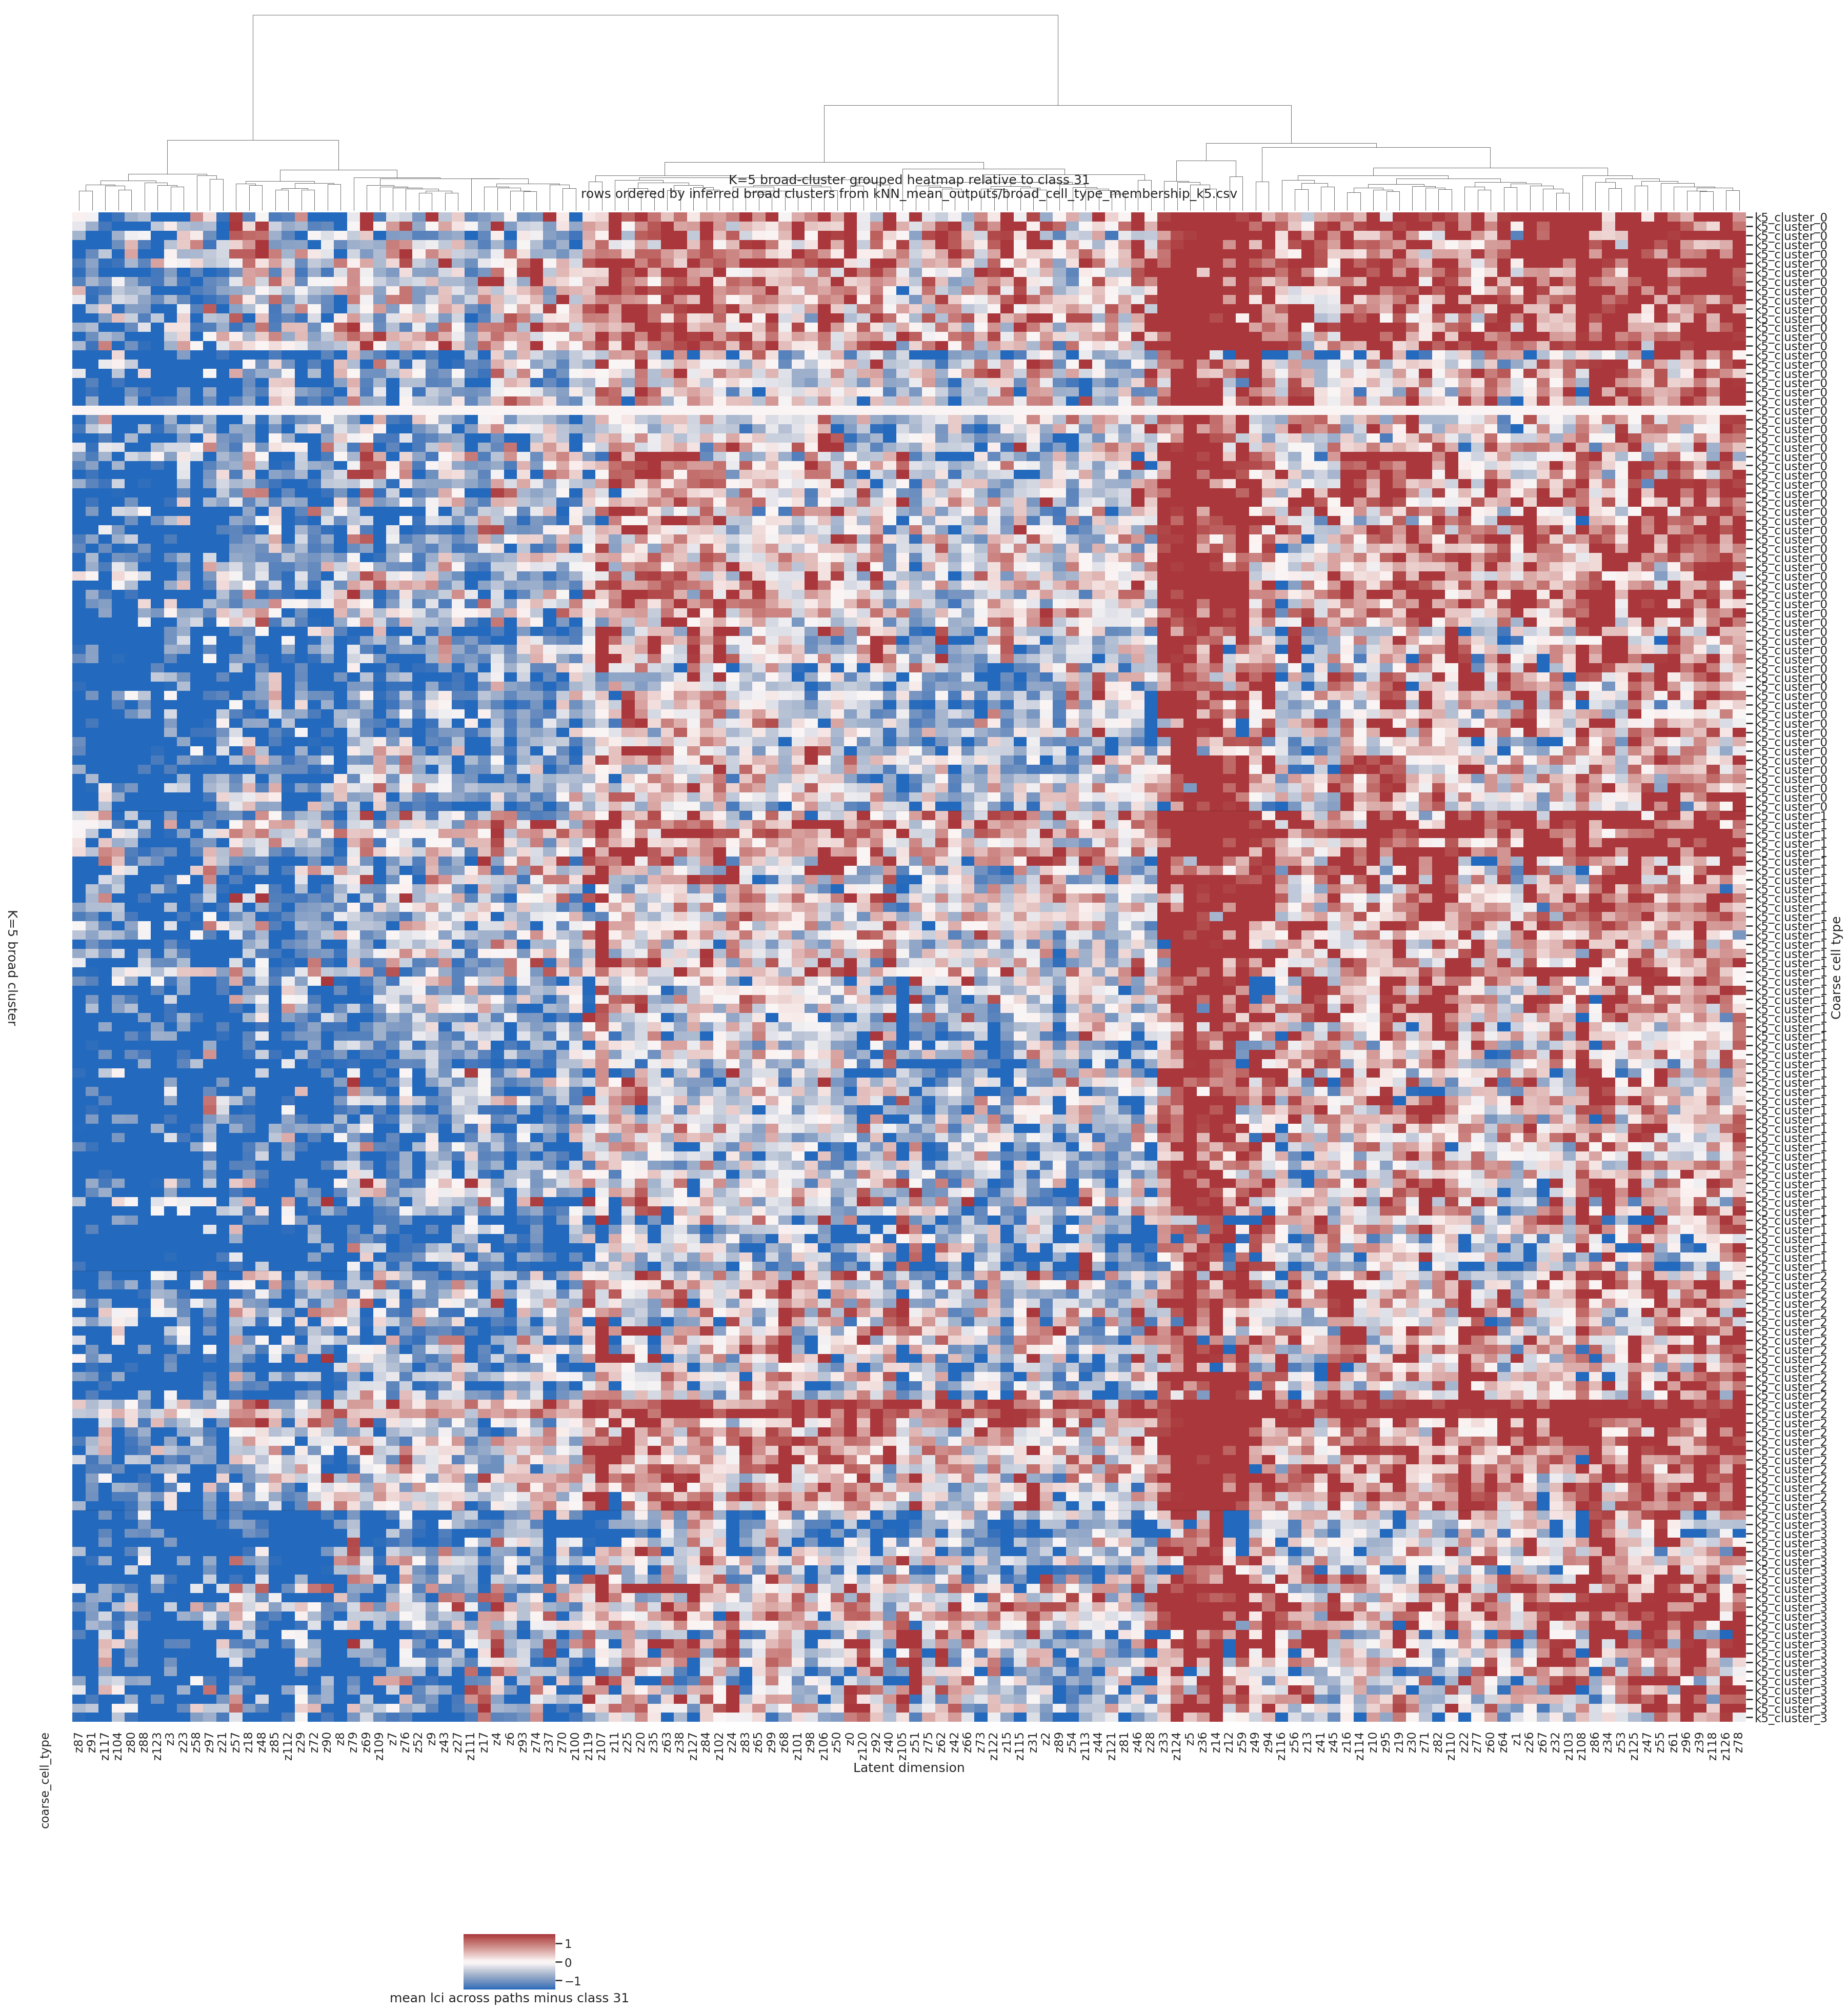

Saved K=5 broad-cluster grouped matrix to: /projects/b1042/GoyalLab/jaekj/KeepingScore/SCTAB_FINAL/Model_softmax/sample_mean_path_3000_true/path_3000_heatmap_analysis_k5/k5_broad_grouped_rel_to_class31_lci_heatmap_top128_vardims.csv
Saved K=5 broad-cluster grouped heatmap to: /projects/b1042/GoyalLab/jaekj/KeepingScore/SCTAB_FINAL/Model_softmax/sample_mean_path_3000_true/path_3000_heatmap_analysis_k5/k5_broad_grouped_rel_to_class31_lci_heatmap_top128_vardims.png
Saved K=5 broad-cluster grouped heatmap to: /projects/b1042/GoyalLab/jaekj/KeepingScore/SCTAB_FINAL/Model_softmax/sample_mean_path_3000_true/path_3000_heatmap_analysis_k5/k5_broad_grouped_rel_to_class31_lci_heatmap_top128_vardims.svg
Detected 4 inferred broad clusters from the K=5 membership file


In [5]:
# ============================================================
# K=5 inferred broad cell-type grouping for the relative lci heatmap
# - uses the saved kNN broad-cell-type membership from cell_type_clustering
# - orders rows by inferred broad cluster, then clusters within each group
# - keeps row blocks fixed so the grouping is preserved in the plot
# ============================================================

if not os.path.isabs(save_dir):
    save_dir = os.path.abspath(save_dir)

if "df_heat_hier" not in globals() or "aligned_lookup" not in globals():
    raise RuntimeError("Run the hierarchy cell first so df_heat_hier and aligned_lookup are available.")

if "infer_name_column" not in globals():
    def infer_name_column(df, preferred=("label", "name", "cell_type", "cell_type_name", "ontology_term_name")):
        for col in preferred:
            if col in df.columns:
                return col
        object_cols = [c for c in df.columns if pd.api.types.is_object_dtype(df[c])]
        if object_cols:
            return object_cols[0]
        return df.columns[0]

if "cluster_within_group" not in globals():

    def cluster_within_group(frame):
        if frame.shape[0] <= 2:
            return frame.index.tolist()
        dist = pdist(frame.to_numpy(), metric="euclidean")
        link = linkage(dist, method="ward")
        return frame.index[leaves_list(link)].tolist()

df_heat_grouped = df_heat_hier.copy()
cell_type_lookup = aligned_lookup.copy()
cell_type_name_col = infer_name_column(cell_type_lookup)

membership_df = pd.read_csv(BROAD_CELL_TYPE_MEMBERSHIP_PATH).copy()
membership_df["cell_type_plot"] = membership_df["cell_type_plot"].astype(str)
membership_df["broad_cluster"] = membership_df["broad_cluster"].astype(str)

def sanitize_plot_label(label):
    label = str(label)
    replacements = {
        "\x07lpha": "alpha",
        "\x08eta": "beta",
        "\\alpha": "alpha",
        "\\beta": "beta",
        "\\gamma": "gamma",
        "$": "",
    }
    for old, new in replacements.items():
        label = label.replace(old, new)
    return " ".join(label.split())

def normalize_cell_type_label(label):
    label = sanitize_plot_label(label).lower().strip()
    replacements = {
        ", human": "",
        " human": "",
        "-positive": "+",
        "-negative": "-",
        " positive": "+",
        " negative": "-",
        "classical": "clas.",
        "memory": "mem.",
        "derived": "der.",
        "thymus-derived": "thym.-der.",
        "terminally differentiated": "term. diff.",
        "projecting": "project.",
        "loop of henle": "loop henle",
        "epithelial": "epith.",
        "descending": "des.",
        "ascending": "asc.",
        "system": "sys.",
        "natural killer cell": "nk cell",
        "double-positive, ": "double+, ",
        "double-positive ": "double+ ",
        "vascular associated": "vascular assoc.",
        "precursor b cell": "pre. b cell",
        "oligodendrocyte precursor cell": "oligodendrocyte pre. cell",
        "intratelencephalic": "it",
    }
    for old, new in replacements.items():
        label = label.replace(old, new)
    return " ".join(label.replace(" ,", ",").split())

membership_df["cell_type_norm"] = membership_df["cell_type_plot"].map(normalize_cell_type_label)
broad_cluster_map = dict(zip(membership_df["cell_type_norm"], membership_df["broad_cluster"]))

alias_map = {
    normalize_cell_type_label("CD8-alpha-alpha-positive, alpha-beta intraepithelial T cell"): normalize_cell_type_label("intraepithelial lymphocyte"),
    normalize_cell_type_label("L2/3-6 intratelencephalic projecting glutamatergic cortical neuron"): normalize_cell_type_label("L2/3-6 IT projecting neuron"),
    normalize_cell_type_label("naive thymus-derived CD4-positive, alpha-beta T cell"): normalize_cell_type_label("naive thym.-der. CD4+, alpha-beta T cell"),
    normalize_cell_type_label("naive thymus-derived CD8-positive, alpha-beta T cell"): normalize_cell_type_label("naive thym.-der. CD8+, alpha-beta T cell"),
}

original_labels = cell_type_lookup[cell_type_name_col].astype(str).tolist()
resolved_norm_labels = []
missing_labels = []
for label in original_labels:
    norm_label = normalize_cell_type_label(label)
    lookup_label = alias_map.get(norm_label, norm_label)
    if lookup_label not in broad_cluster_map:
        missing_labels.append(label)
    resolved_norm_labels.append(lookup_label)

if missing_labels:
    raise ValueError(
        f"{len(missing_labels)} cell types are missing from the K=5 broad-cluster mapping. "
        f"Examples: {missing_labels[:10]}"
    )

display_labels = [f"k5_cluster_{sanitize_plot_label(broad_cluster_map[label])}" for label in resolved_norm_labels]

group_labels = np.array(display_labels, dtype=object)
row_annotations = pd.DataFrame(
    {
        "original_cell_type": original_labels,
        "coarse_cell_type": group_labels,
    },
    index=df_heat_grouped.index,
)

ordered_index = []
group_boundaries = []
for coarse_name in sorted(pd.unique(row_annotations["coarse_cell_type"])):
    members = row_annotations.index[row_annotations["coarse_cell_type"] == coarse_name]
    ordered_members = cluster_within_group(df_heat_grouped.loc[members])
    ordered_index.extend(ordered_members)
    group_boundaries.append(len(ordered_index))

df_group_ordered = df_heat_grouped.loc[ordered_index].copy()
row_annotations = row_annotations.loc[ordered_index].copy()
df_group_ordered.index = row_annotations["coarse_cell_type"].tolist()

n_groups = row_annotations["coarse_cell_type"].nunique()
palette = sns.color_palette("husl", n_colors=max(n_groups, 1))
group_to_color = dict(zip(sorted(pd.unique(row_annotations["coarse_cell_type"])), palette))
row_colors = row_annotations["coarse_cell_type"].map(group_to_color)

sns.set_context("talk")
sns.set_style("white")

g = sns.clustermap(
    df_group_ordered,
    cmap="vlag",
    center=0,
    vmin=display_vmin,
    vmax=display_vmax,
    row_cluster=False,
    col_cluster=True,
    row_colors=row_colors,
    metric="euclidean",
    method="ward",
    linewidths=0.0,
    xticklabels=True,
    yticklabels=True,
    figsize=(max(15, 0.28 * df_group_ordered.shape[1]), max(12, 0.22 * len(row_annotations))),
    dendrogram_ratio=(0.0, 0.12),
    cbar_pos=(0.25, -0.08, 0.05, 0.03)
)

g.cax.set_xlabel(f"mean lci across paths minus class {ref_class}")
g.cax.xaxis.set_label_position('bottom')

for boundary in group_boundaries[:-1]:
    g.ax_heatmap.hlines(boundary, *g.ax_heatmap.get_xlim(), colors="black", linewidth=0.35, alpha=0.35)

g.ax_heatmap.set_title(
    f"K=5 broad-cluster grouped heatmap relative to class {ref_class}\n"
    f"rows ordered by inferred broad clusters from kNN_mean_outputs/broad_cell_type_membership_k5.csv",
    pad=20,
)
g.ax_heatmap.set_xlabel("Latent dimension")
g.ax_heatmap.set_ylabel("Coarse cell type")
g.ax_row_colors.set_ylabel("K=5 broad cluster", rotation=270, labelpad=20)

yaml_png = os.path.join(
    analysis_dir,
    f"k5_broad_grouped_rel_to_class{ref_class}_lci_heatmap_top{df_group_ordered.shape[1]}_vardims.png",
)
yaml_svg = os.path.join(
    analysis_dir,
    f"k5_broad_grouped_rel_to_class{ref_class}_lci_heatmap_top{df_group_ordered.shape[1]}_vardims.svg",
)
g.fig.savefig(yaml_png, dpi=300, bbox_inches="tight")
g.fig.savefig(yaml_svg, dpi=300, bbox_inches="tight")
plt.show()

col_order = g.dendrogram_col.reordered_ind
df_yaml_reordered = df_group_ordered.iloc[:, col_order].copy()
df_yaml_reordered.insert(0, "coarse_cell_type", row_annotations["coarse_cell_type"].to_numpy())
df_yaml_reordered.insert(0, "original_cell_type", row_annotations["original_cell_type"].to_numpy())

yaml_out_csv = os.path.join(
    analysis_dir,
    f"k5_broad_grouped_rel_to_class{ref_class}_lci_heatmap_top{df_group_ordered.shape[1]}_vardims.csv",
)
df_yaml_reordered.to_csv(yaml_out_csv)
print(f"Saved K=5 broad-cluster grouped matrix to: {yaml_out_csv}")
print(f"Saved K=5 broad-cluster grouped heatmap to: {yaml_png}")
print(f"Saved K=5 broad-cluster grouped heatmap to: {yaml_svg}")
print(f"Detected {n_groups} inferred broad clusters from the K=5 membership file")

/projects/b1042/GoyalLab/jaekj/python/scTAB_new/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


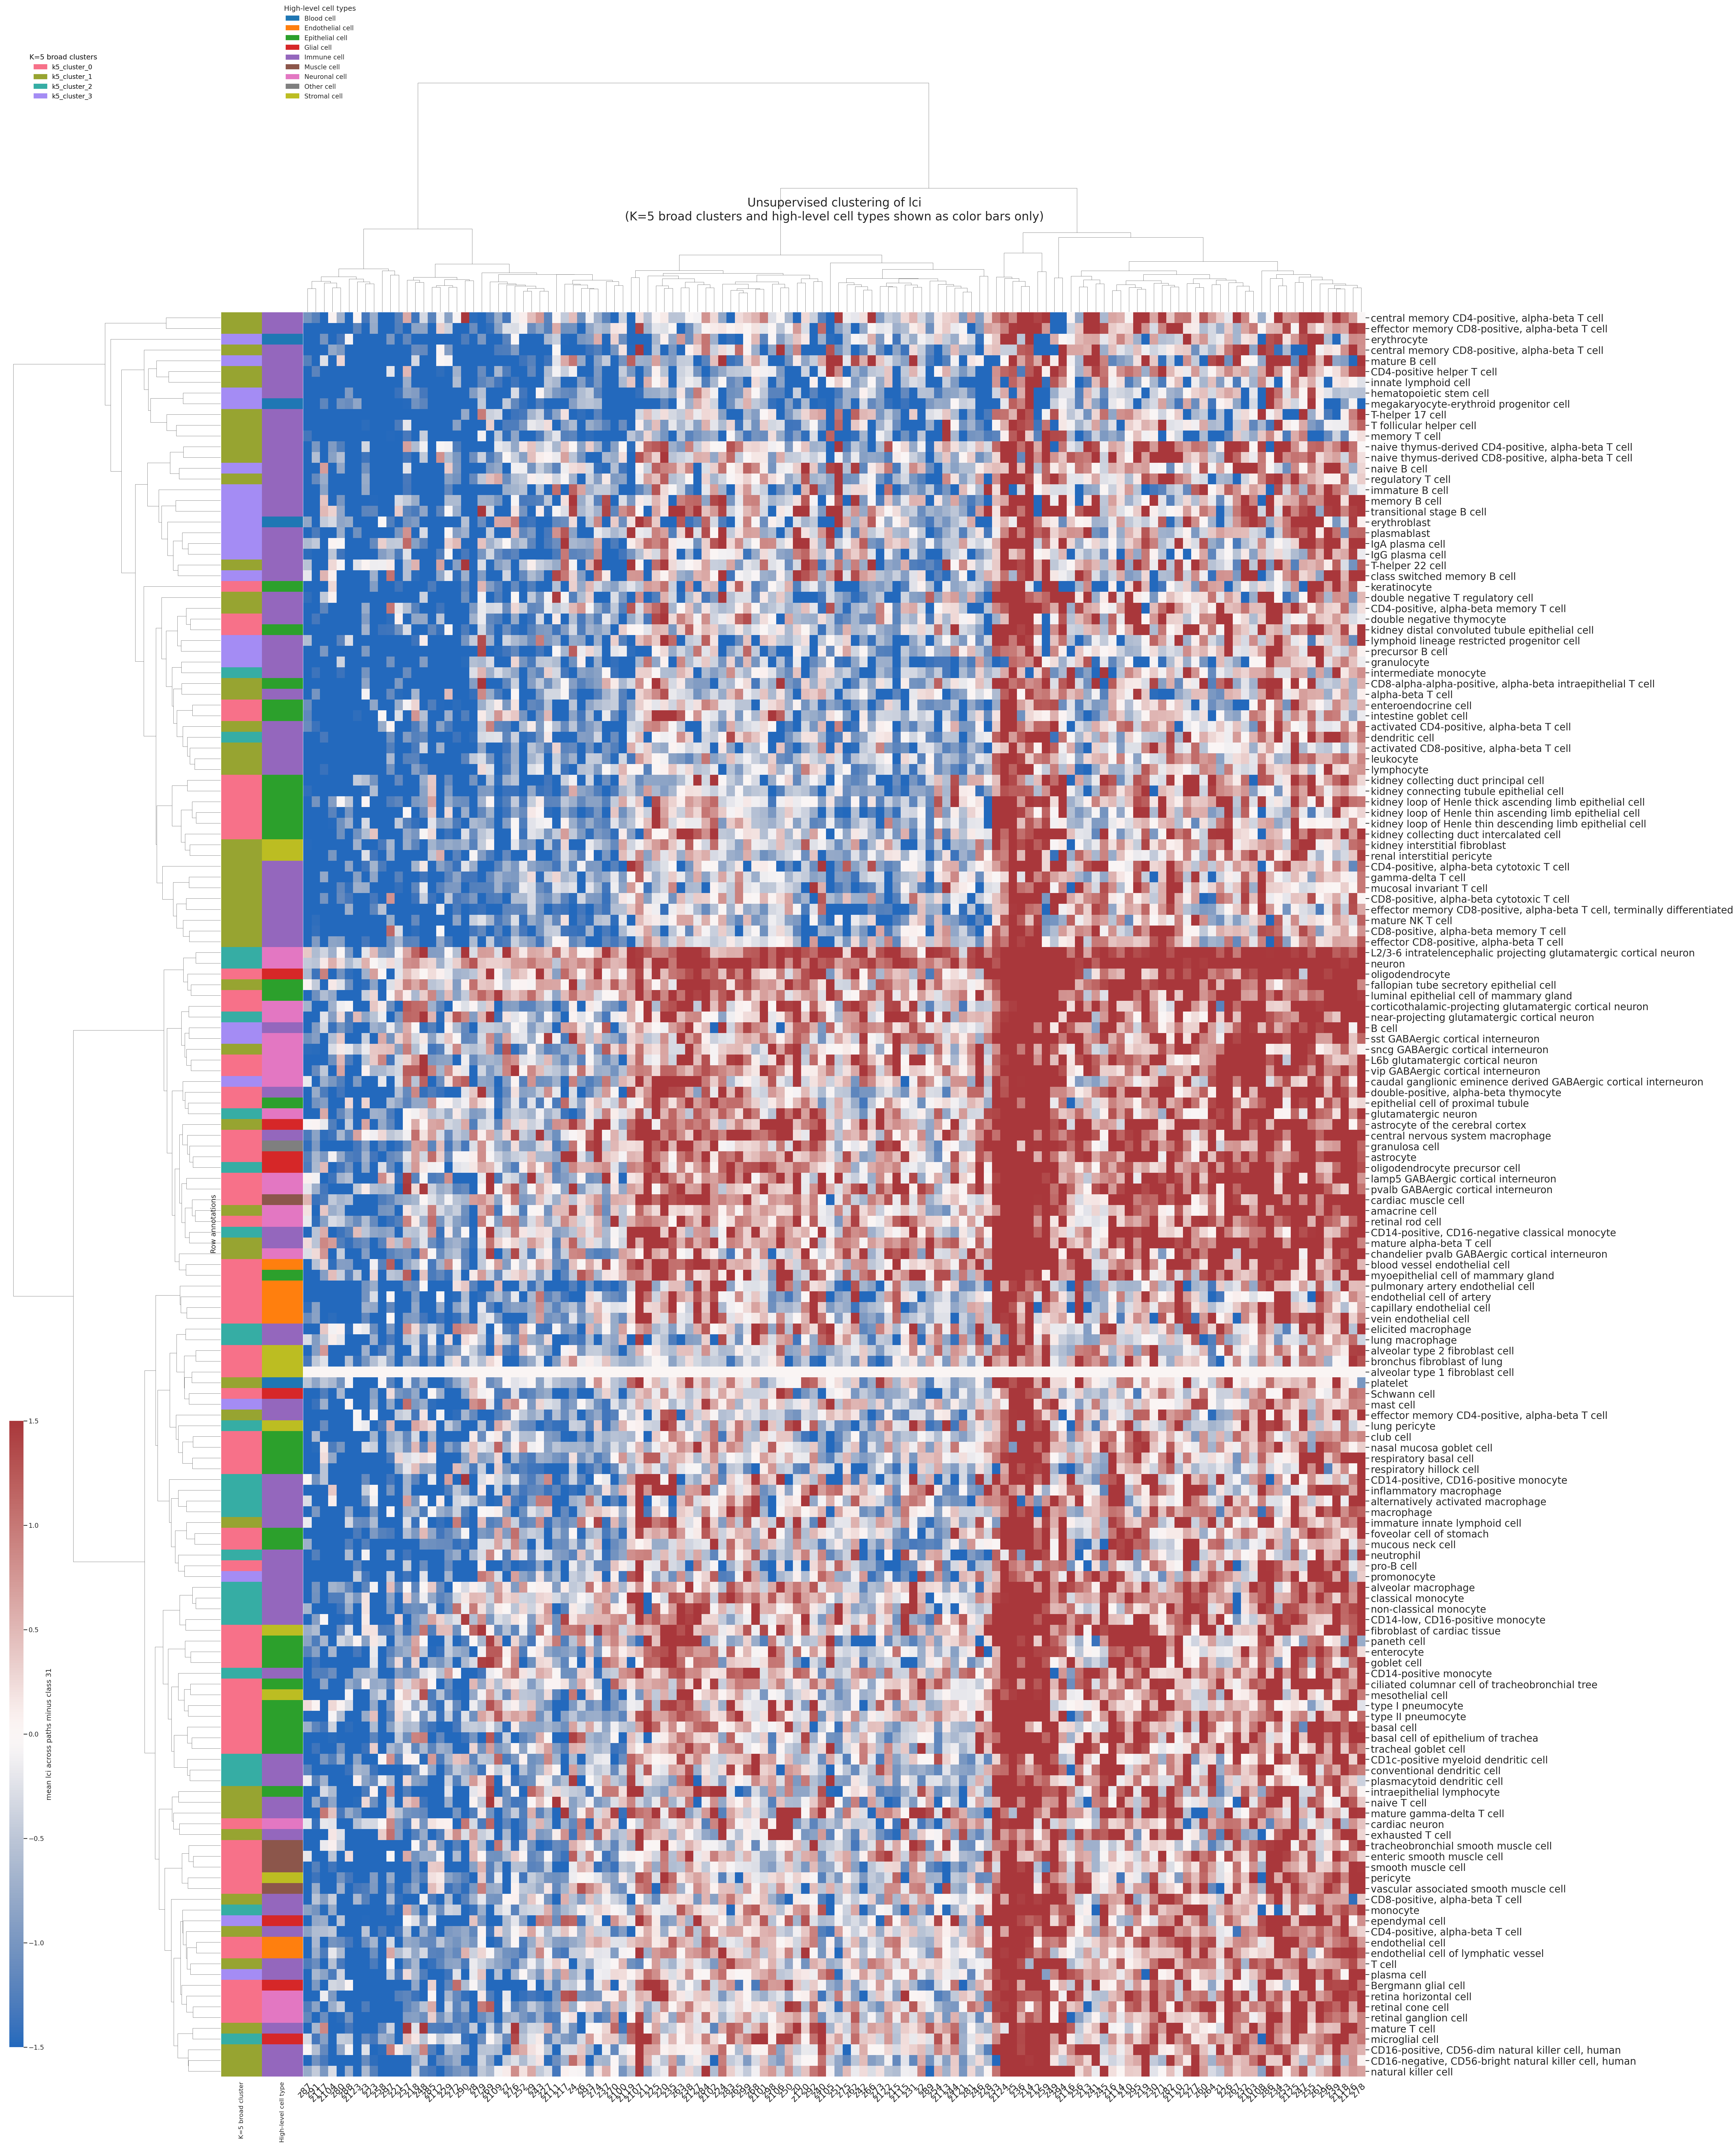

In [6]:
# ============================================
# TRUE unsupervised clustering + annotations
# ============================================

# Keep original labels (fine cell types)
df_plot = df_heat_hier.copy()

if "HIGH_LEVEL_CELLTYPE_PATH" not in globals():
    HIGH_LEVEL_CELLTYPE_PATH = "/projects/b1042/GoyalLab/jaekj/KeepingScore/SCTAB_FINAL/Model_softmax/high-level-celltype.yaml"

with open(HIGH_LEVEL_CELLTYPE_PATH, "r") as f:
    high_level_celltype_map = yaml.safe_load(f)

# Build annotations
row_annotations = pd.DataFrame(
    {
        "cell_type": original_labels,
        "coarse_cell_type": group_labels,
        "high_level_cell_type": [high_level_celltype_map.get(label) for label in original_labels],
    },
    index=df_plot.index,
)

missing_high_level = row_annotations.loc[
    row_annotations["high_level_cell_type"].isna(), "cell_type"
].tolist()
if missing_high_level:
    raise ValueError(
        f"{len(missing_high_level)} cell types are missing from {HIGH_LEVEL_CELLTYPE_PATH}. "
        f"Examples: {missing_high_level[:10]}"
    )

# Color bars for annotations. Keep K=5 cluster colors separate from YAML high-level colors.
coarse_palette = sns.color_palette("husl", n_colors=len(np.unique(group_labels)))
group_to_color = dict(zip(sorted(np.unique(group_labels)), coarse_palette))

high_level_groups = sorted(row_annotations["high_level_cell_type"].unique())
high_level_palette = sns.color_palette("tab10", n_colors=len(high_level_groups))
high_level_to_color = dict(zip(high_level_groups, high_level_palette))

row_colors = pd.DataFrame(
    {
        "K=5 broad cluster": row_annotations["coarse_cell_type"].map(group_to_color),
        "High-level cell type": row_annotations["high_level_cell_type"].map(high_level_to_color),
    },
    index=df_plot.index,
)

# --- CLUSTERMAP ---
g = sns.clustermap(
    df_plot,
    cmap="vlag",
    center=0,
    vmin=display_vmin,
    vmax=display_vmax,

    # TRUE clustering
    row_cluster=True,
    col_cluster=True,

    row_colors=row_colors,   # annotation only (NOT used for clustering)

    metric="euclidean",
    method="ward",

    xticklabels=True,
    yticklabels=True,

    figsize=(max(50, 0.34 * df_plot.shape[1]), max(20, 0.45 * df_plot.shape[0])),
    dendrogram_ratio=(0.16, 0.12),

    cbar_kws={"label": f"mean lci across paths minus class {ref_class}"},
    cbar_pos=(0.01, 0.05, 0.01, 0.3)
)

# --- create legend handles ---
coarse_legend_handles = [
    mpatches.Patch(color=group_to_color[group], label=group)
    for group in sorted(group_to_color.keys())
]
high_level_legend_handles = [
    mpatches.Patch(color=high_level_to_color[group], label=group)
    for group in high_level_groups
]

# --- add legends ---
coarse_legend = g.fig.legend(
    handles=coarse_legend_handles,
    title="K=5 broad clusters",
    loc="lower left",
    bbox_to_anchor=(0.02, 0.98),
    frameon=False,
)
g.fig.add_artist(coarse_legend)

g.fig.legend(
    handles=high_level_legend_handles,
    title="High-level cell types",
    loc="lower left",
    bbox_to_anchor=(0.20, 0.98),
    frameon=False,
)

# --- label formatting ---
# Get clustered row order
row_order = g.dendrogram_row.reordered_ind

# Apply correct ordering to labels
ordered_labels = row_annotations.iloc[row_order]["cell_type"].values

g.ax_heatmap.set_yticklabels(ordered_labels, fontsize=25)
g.ax_heatmap.set_title(
    "Unsupervised clustering of lci\n(K=5 broad clusters and high-level cell types shown as color bars only)",
    pad=10,
    y=1.05,
    x=0.5,
    fontsize=30
)

# Label the annotation color bars on the left side.
g.ax_row_colors.set_ylabel("Row annotations", labelpad=10, ha="right")
g.ax_row_colors.set_xticks(np.arange(row_colors.shape[1]) + 0.5)
g.ax_row_colors.set_xticklabels(row_colors.columns, rotation=90, fontsize=16)
g.ax_heatmap.tick_params(axis='y', pad=5)

g.ax_row_colors.yaxis.set_label_position("left")
g.ax_row_colors.yaxis.tick_left()
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=25)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=23)

plt.setp(
    g.ax_heatmap.get_xticklabels(),
    rotation=45,
    ha="right",
    rotation_mode="anchor"
)

clustered_png = os.path.join(
    analysis_dir,
    f"k5_broad_grouped_rel_to_class{ref_class}_lci_heatmap_top{df_group_ordered.shape[1]}_clustered.png",
)
clustered_svg = os.path.join(
    analysis_dir,
    f"k5_broad_grouped_rel_to_class{ref_class}_lci_heatmap_top{df_group_ordered.shape[1]}_clustered.svg",
)
g.fig.savefig(clustered_png, dpi=300, bbox_inches="tight")
g.fig.savefig(clustered_svg, dpi=300, bbox_inches="tight")

plt.show()


### Permutation test

In [7]:
# ============================================
# Use CLUSTERED order (CRITICAL FIX)
# ============================================

# Get clustering order
row_order = g.dendrogram_row.reordered_ind

# Reorder matrix and labels
X = df_plot.iloc[row_order].copy()
# Optional sanity check (should be centered around 0)
print("Mean of matrix (should be ~0):", X.mean())

labels = row_annotations.iloc[row_order]["coarse_cell_type"].values

print("Using clustered row order")
print("Matrix shape:", X.shape)

Mean of matrix (should be ~0): z49     0.590568
z12     0.909172
z94     0.623939
z105   -0.426946
z59     1.292367
          ...   
z27    -0.569407
z121   -0.383126
z9     -0.608424
z81    -0.279347
z99     0.253382
Length: 128, dtype: float32
Using clustered row order
Matrix shape: (164, 128)


In [8]:
# ============================================
# Pairwise Euclidean distances (precompute)
# ============================================

from scipy.spatial.distance import pdist, squareform

dist_vec = pdist(X, metric="euclidean")   # condensed form
dist_mat = squareform(dist_vec)           # [N, N]

print("Distance matrix shape:", dist_mat.shape)

Distance matrix shape: (164, 164)


In [9]:
# ============================================
# Compute within / between distances
# ============================================

def compute_within_between(dist_mat, labels):
    """
    Returns:
        mean_within, mean_between
    """
    labels = np.asarray(labels)
    N = len(labels)

    # Build mask matrices
    same = labels[:, None] == labels[None, :]
    diff = ~same

    # Remove diagonal
    np.fill_diagonal(same, False)
    np.fill_diagonal(diff, False)

    # Extract values
    within_vals = dist_mat[same]
    between_vals = dist_mat[diff]

    return within_vals.mean(), between_vals.mean()

In [10]:
# ============================================
# Observed (non-randomized)
# ============================================

mean_w_obs, mean_b_obs = compute_within_between(dist_mat, labels)
delta_obs = mean_b_obs - mean_w_obs

print("Observed:")
print("  <r_ij>_w =", mean_w_obs)
print("  <r_ij>_b =", mean_b_obs)
print("  delta    =", delta_obs)

Observed:
  <r_ij>_w = 15.92207556736674
  <r_ij>_b = 17.060470103842384
  delta    = 1.1383945364756443


In [11]:
# ============================================
# Permutation test
# ============================================

mean_w_list = []
mean_b_list = []
delta_list  = []

rng = np.random.default_rng(seed=42)

for i in range(n_perm):
    shuffled_labels = rng.permutation(labels)

    mw, mb = compute_within_between(dist_mat, shuffled_labels)

    mean_w_list.append(mw)
    mean_b_list.append(mb)
    delta_list.append(mb - mw)

    if i % 200 == 0:
        print(f"Permutation {i}/{n_perm}")

mean_w_arr = np.array(mean_w_list)
mean_b_arr = np.array(mean_b_list)
delta_arr  = np.array(delta_list)

Permutation 0/100000


Permutation 200/100000
Permutation 400/100000
Permutation 600/100000
Permutation 800/100000
Permutation 1000/100000
Permutation 1200/100000
Permutation 1400/100000
Permutation 1600/100000
Permutation 1800/100000
Permutation 2000/100000
Permutation 2200/100000
Permutation 2400/100000
Permutation 2600/100000
Permutation 2800/100000
Permutation 3000/100000
Permutation 3200/100000
Permutation 3400/100000
Permutation 3600/100000
Permutation 3800/100000
Permutation 4000/100000
Permutation 4200/100000
Permutation 4400/100000
Permutation 4600/100000
Permutation 4800/100000
Permutation 5000/100000
Permutation 5200/100000
Permutation 5400/100000
Permutation 5600/100000
Permutation 5800/100000
Permutation 6000/100000
Permutation 6200/100000
Permutation 6400/100000
Permutation 6600/100000
Permutation 6800/100000
Permutation 7000/100000
Permutation 7200/100000
Permutation 7400/100000
Permutation 7600/100000
Permutation 7800/100000
Permutation 8000/100000
Permutation 8200/100000
Permutation 8400/100

In [12]:
# ============================================
# Save results
# ============================================

out_dir = os.path.join(save_dir, "permutation_test")
os.makedirs(out_dir, exist_ok=True)

np.save(os.path.join(out_dir, "mean_within.npy"), mean_w_arr)
np.save(os.path.join(out_dir, "mean_between.npy"), mean_b_arr)
np.save(os.path.join(out_dir, "delta.npy"), delta_arr)

print("Saved permutation results to:", out_dir)

Saved permutation results to: /projects/b1042/GoyalLab/jaekj/KeepingScore/SCTAB_FINAL/Model_softmax/sample_mean_path_3000_true/permutation_test


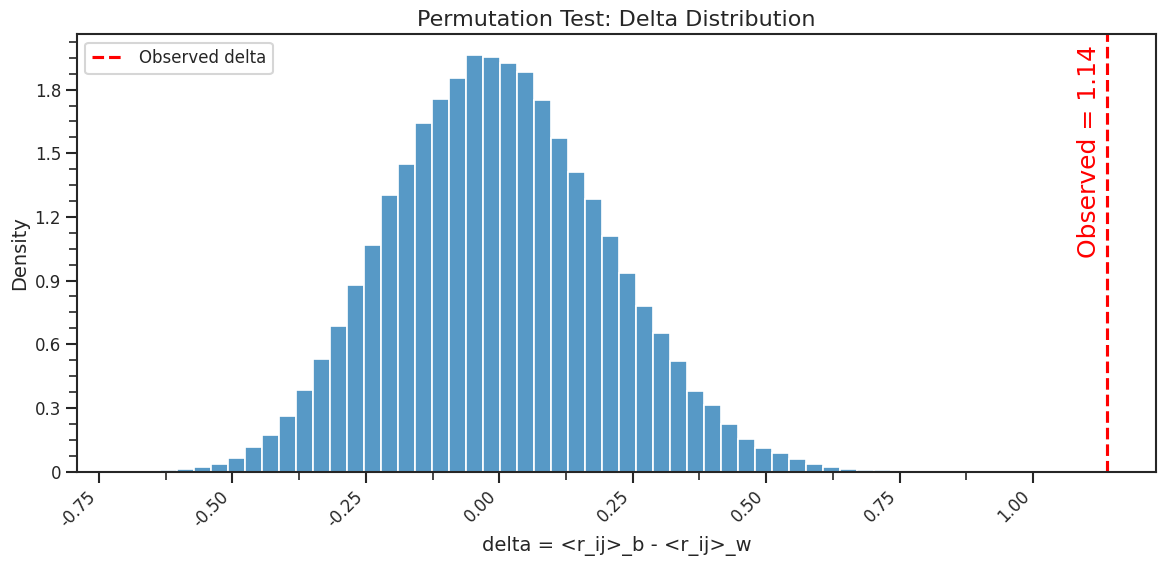

In [13]:
import matplotlib.ticker as mticker
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

counts, bin_edges = np.histogram(delta_arr, bins=50)

sns.histplot(delta_arr, bins=bin_edges, stat="density", kde=False, ax=ax)
ax.axvline(delta_obs, color="red", linestyle="--", label="Observed delta")

x_min = min(delta_arr.min(), delta_obs)
x_max = max(delta_arr.max(), delta_obs)
x_pad = 0.05 * (x_max - x_min if x_max > x_min else 1.0)
x_lower = x_min - x_pad
x_upper = x_max + x_pad

ax.set_xscale("linear")
ax.set_xlim(x_lower, x_upper)

ax.set_xlabel("delta = <r_ij>_b - <r_ij>_w", fontsize=14)
ax.set_ylabel("Density", fontsize=14)
ax.set_title("Permutation Test: Delta Distribution", fontsize=16)

# Keep the x-axis in the original delta units.
x_major_ticks = mticker.MaxNLocator(nbins=10).tick_values(x_lower, x_upper)
x_major_ticks = x_major_ticks[(x_major_ticks >= x_lower) & (x_major_ticks <= x_upper)]
x_major_ticks = np.unique(np.round(x_major_ticks, 6))
ax.set_xticks(x_major_ticks)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:.2f}"))

if len(x_major_ticks) >= 2:
    x_minor_ticks = (x_major_ticks[:-1] + x_major_ticks[1:]) / 2
    ax.set_xticks(x_minor_ticks, minor=True)

ax.set_yscale("linear")
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=8))
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:g}"))

ax.tick_params(axis='x', which='major', bottom=True, top=False, direction='out', length=8, width=1.5, labelsize=12, rotation=45)
ax.tick_params(axis='x', which='minor', bottom=True, top=False, direction='out', length=6, width=1.2)
ax.tick_params(axis='y', which='major', left=True, right=False, direction='out', length=8, width=1.5, labelsize=12)
ax.tick_params(axis='y', which='minor', left=True, right=False, direction='out', length=6, width=1.2)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

for tick in ax.get_xticklabels():
    tick.set_ha("right")

ax.annotate(
    f"Observed = {delta_obs:.2f}",
    xy=(delta_obs, 1),
    xycoords=("data", "axes fraction"),
    xytext=(-4, -8),
    textcoords="offset points",
    ha="right",
    va="top",
    color="red",
    rotation=90,
)

ax.margins(x=0)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(permutation_dir, "delta_distribution.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(permutation_dir, "delta_distribution.svg"), dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# ============================================
# p-value computation
# ============================================

# One-sided (between > within)
# p_value = np.mean(delta_arr >= delta_obs)
p_value = (np.sum(delta_arr >= delta_obs) + 1) / (n_perm + 1)

# Two-sided (optional)
# p_value_two_sided = np.mean(np.abs(delta_arr) >= np.abs(delta_obs))
p_value_two_sided = (np.sum(np.abs(delta_arr) >= np.abs(delta_obs)) + 1) / (n_perm + 1)

print(f"P-value (one-sided): {p_value:.2e}")
print(f"P-value (two-sided): {p_value_two_sided:.2e}")

P-value (one-sided): 1.00e-05
P-value (two-sided): 1.00e-05


### Silhouette score

In [15]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, labels, metric="euclidean")
print("Silhouette score:", score)

Silhouette score: -0.01239383


In [16]:
scores_perm = []

n_perm_shil = 1000 
for i in range(n_perm_shil):
    shuffled = np.random.permutation(labels)
    s = silhouette_score(X, shuffled, metric="euclidean")
    scores_perm.append(s)

scores_perm = np.array(scores_perm)

p_val = np.mean(scores_perm >= score)
print("Permutation p-value (silhouette):", p_val)

Permutation p-value (silhouette): 0.027
